In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import scipy.stats as stats

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})

Inits:

In [2]:
full_data = pd.read_pickle('multifiber.pickle') # use for activity comparisons 

# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping
clusters = np.unique(full_data['91R2_d1_balbc_t1']['unsupervised labels'])
print(clusters)
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]


Get activity for all clusters:

In [3]:
def filter_for_consecutive_segments(idxs, min_length=20):
	"""
	Filter indices to keep only consecutive segments with at least min_length elements.
	
	Parameters:
	-----------
	idxs : array-like
		List or array of indices
	min_length : int
		Minimum length of consecutive segments to keep (default: 20)
	
	Returns:
	--------
	filtered_idxs : numpy array
		Filtered indices containing only segments with min_length or more consecutive elements
	"""
	if len(idxs) == 0:
		return np.array([])
	
	idxs = np.array(idxs)
	idxs_sorted = np.sort(idxs)
	
	# Find where consecutive sequences break
	breaks = np.where(np.diff(idxs_sorted) > 1)[0]
	
	# Add start and end points
	segment_starts = np.concatenate([[0], breaks + 1])
	segment_ends = np.concatenate([breaks + 1, [len(idxs_sorted)]])
	
	# Keep only segments with length >= min_length
	filtered_segments = []
	for start, end in zip(segment_starts, segment_ends):
		segment_length = end - start
		if segment_length >= min_length:
			filtered_segments.extend(idxs_sorted[start:end])
	
	return np.array(filtered_segments)

In [4]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
all_activity = np.zeros((len(clusters), len(region_ids), 27, len(animals)))
all_activity[:] = np.nan

region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations

for a, animal in enumerate(animals):
	
	if a<=11:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_balbc_' in x or '_mCD1_' in x]
	elif a<=20:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
	else:
		sessions = [x for x in list(full_data.keys()) if animal in x if '_toy_' in x or '_toyCD1_' in x]
		
	for s, session in enumerate(sessions):
		
		sample = full_data[session]
		activity_per_cluster = np.zeros((len(clusters), all_activity.shape[1]))

		for i, c in enumerate(clusters):
			idxs2extract = np.where(sample['unsupervised labels'] == c)[0]
			idxs2extract = filter_for_consecutive_segments(idxs2extract, min_length=4) # Filter consecutive segments smaller than 100ms; protects against outliers in the averaging process
			for r, roi in enumerate(region_ids):
				if len(idxs2extract)==0:
					activity_per_cluster[i, r] = np.nan
				else:
					activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])

		# Perform ranking
		all_activity[:, :, s, a] = activity_per_cluster
		

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\1759166577.py:31: RuntimeWarning: Mean of empty slice
  activity_per_cluster[i, r] = np.nanmean(sample[roi].iloc[idxs2extract])


### Neural activity differences during hard fight

1. Set up data

In [5]:
def compute_activity(grid, cluster_ids, n_animals):
	"""
	Fixed version of compute_activity.
	Extracts activity for selected clusters from the grid.
	
	Parameters
	----------
	grid : ndarray, shape (n_total_clusters, n_rois, n_sessions, n_animals)
	cluster_ids : array-like, cluster indices to include
	n_animals : int
	
	Returns
	-------
	activity_grid : ndarray, shape (n_clusters, n_rois, n_sessions, n_animals)
	"""
	n_rois = grid.shape[1]
	n_sessions = grid.shape[2]
	activity_grid = np.full((len(cluster_ids), n_rois, n_sessions, n_animals), np.nan)
	
	for a in range(min(n_animals, grid.shape[-1])):
		for i in range(n_rois):
			for ci, c in enumerate(cluster_ids):
				activity_grid[ci, i, :, a] = grid[c, i, :, a]
	
	return activity_grid

# For computing EI indices
total_sessions = 27
n_animals = 29
n_rois = len(region_ids)

# Grab activity during aggression subclusters
n_clusters = [0, 1, 2, 3, 4, 6, 7, 8] # social behavior clusters
prep_activity_data = compute_activity(all_activity, np.array(n_clusters), n_animals=n_animals) 
n_clusters = [10, 11, 12] # nonsocial behavior clusters used for normalization
asocial_activity_data = compute_activity(all_activity, np.array(n_clusters), n_animals=n_animals)

# For saving
prep_dists = np.zeros((total_sessions, n_rois, n_animals))
prep_dists[:] = np.nan
asocial_dists = prep_dists.copy()

for animal in np.arange(prep_activity_data.shape[-1]):
	for roi in np.arange(n_rois):
		sample1 = prep_activity_data[:, roi, :, animal]
		sample2 = asocial_activity_data[:, roi, :, animal]
		for i in enumerate(np.arange(sample1.shape[1])):
			prep_dists[i,roi,animal] = np.nanmean(prep_activity_data[:, roi, i, animal]) # mean
			asocial_dists[i,roi,animal] = np.nanmean(asocial_activity_data[:, roi, i, animal]) # mean

all_dists = prep_dists - asocial_dists

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\817262071.py:48: RuntimeWarning: Mean of empty slice
  prep_dists[i,roi,animal] = np.nanmean(prep_activity_data[:, roi, i, animal]) # mean
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\817262071.py:49: RuntimeWarning: Mean of empty slice
  asocial_dists[i,roi,animal] = np.nanmean(asocial_activity_data[:, roi, i, animal]) # mean


In [6]:
# animal-by-animal averaging
aggression_related_activity = all_dists[-3:, :, :]
aggression_related_activity = np.nanmean(aggression_related_activity, axis=0)
agg_activity = aggression_related_activity[:, :12]
obs_activity = aggression_related_activity[:, 12:21]
non_activity = aggression_related_activity[:, 21:]

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\3199762345.py:3: RuntimeWarning: Mean of empty slice
  aggression_related_activity = np.nanmean(aggression_related_activity, axis=0)


2. Assess hard fight

In [28]:
# Statistical testing functions (normality -> variance -> omnibus -> posthoc)

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, levene, bartlett, f_oneway, kruskal, ttest_ind, brunnermunzel

def anova_stats(data2plot, alpha=0.05, variance_alpha=0.05, posthoc_alpha=0.05, kind='fdr_bh'):
    """
    1) Normality (Shapiro, per group)
    2) Variance (Levene always; Bartlett too if all normal)
    3) Omnibus: ANOVA (normal+equal var) / Welch ANOVA (normal+unequal var)
       / Kruskal-Wallis (non-normal)
    4) Posthoc (gated by omnibus p<=posthoc_alpha): t-test / Welch t-test /
       Brunner-Munzel, FDR-corrected across the 3 pairwise comparisons

    Parameters:
    -----------
    data2plot : list of arrays
        [agg_data, obs_data, non_data]
    alpha : float
        Alpha level for normality and variance tests (default 0.05)
    variance_alpha : float
        Alpha level for variance homogeneity tests (default 0.05)
    posthoc_alpha : float
        Alpha level for triggering post-hoc tests (default 0.05)
    kind : str
        Multiple comparisons correction method (default 'fdr_bh')
    """

    # Clean data
    agg_roi_activity = data2plot[0][~np.isnan(data2plot[0])]
    obs_roi_activity = data2plot[1][~np.isnan(data2plot[1])]
    non_roi_activity = data2plot[2][~np.isnan(data2plot[2])]

    df = pd.DataFrame({
        'Activity': np.concatenate([agg_roi_activity, obs_roi_activity, non_roi_activity]),
        'Group': np.concatenate([
            ['agg'] * len(agg_roi_activity),
            ['obs'] * len(obs_roi_activity),
            ['non'] * len(non_roi_activity)
        ])
    })

    # ── 1. Normality ────────────────────────────────────────────────────────────
    normality_results = _test_group_normality(
        [agg_roi_activity, obs_roi_activity, non_roi_activity],
        ['agg', 'obs', 'non'],
        alpha
    )

    # ── 2. Variance ───────────────────────────────────────────────────────────────
    variance_results = _test_variance_homogeneity(
        agg_roi_activity, obs_roi_activity, non_roi_activity, alpha, variance_alpha,
        normality_results['all_normal']
    )

    # ── 3. Omnibus ────────────────────────────────────────────────────────────────
    if normality_results['all_normal']:
        omnibus_results = _perform_anova(df)
        test_family = "parametric"
        pairwise_test = 't-test'
    else:
        omnibus_results = _perform_kruskal_wallis(
            agg_roi_activity, obs_roi_activity, non_roi_activity
        )
        test_family = "non-parametric"
        pairwise_test = 'Brunner-Munzel'

    # ── 4. Posthoc (gated by omnibus p <= posthoc_alpha) ───────────────────────────
    posthoc_results = None
    if omnibus_results['p_value'] <= posthoc_alpha:
        posthoc_results = _perform_posthoc_tests(
            agg_roi_activity, obs_roi_activity, non_roi_activity,
            pairwise_test, kind
        )

    results = {
        'omnibus': omnibus_results,
        'normality': normality_results,
        'variance': variance_results,
        'posthoc': posthoc_results,
        'test_family': test_family,
        'pairwise_test': pairwise_test,
        'sample_sizes': {
            'agg': len(agg_roi_activity),
            'obs': len(obs_roi_activity),
            'non': len(non_roi_activity)
        },
        'descriptives': {
            'agg': {'mean': np.mean(agg_roi_activity), 'std': np.std(agg_roi_activity)},
            'obs': {'mean': np.mean(obs_roi_activity), 'std': np.std(obs_roi_activity)},
            'non': {'mean': np.mean(non_roi_activity), 'std': np.std(non_roi_activity)}
        }
    }

    _print_results(results)

    return results


def _test_group_normality(groups, group_names, alpha):
    """Normality testing for multiple groups (Shapiro; D'Agostino-Pearson if n>=20)."""
    results = {'groups': {}, 'all_normal': True}

    for group, name in zip(groups, group_names):
        if len(group) < 8:
            results['groups'][name] = {'normal': False, 'reason': "Sample too small", 'tests': {}}
            results['all_normal'] = False
            continue

        _, p_shapiro = shapiro(group)
        tests = {'shapiro': p_shapiro}

        if len(group) >= 20:
            _, p_dagostino = stats.normaltest(group)
            tests['dagostino'] = p_dagostino
            is_normal = (p_shapiro > alpha) and (p_dagostino > alpha)
        else:
            is_normal = p_shapiro > alpha

        results['groups'][name] = {'normal': is_normal, 'tests': tests}
        if not is_normal:
            results['all_normal'] = False

    return results


def _test_variance_homogeneity(agg, obs, non, alpha, variance_alpha, normality_passed):
    """Levene's test always; Bartlett's too if normality holds."""
    stat_levene, p_levene = levene(agg, obs, non)
    equal_variances = p_levene > variance_alpha

    result = {
        'equal_variances': equal_variances,
        'levene': {'statistic': stat_levene, 'p_value': p_levene},
    }

    if normality_passed:
        stat_bartlett, p_bartlett = bartlett(agg, obs, non)
        equal_variances = equal_variances and (p_bartlett > variance_alpha)
        result['equal_variances'] = equal_variances
        result['bartlett'] = {'statistic': stat_bartlett, 'p_value': p_bartlett}

    return result


def _perform_anova(df):
    """One-way ANOVA (normal + equal variance)."""
    model = ols('Activity ~ C(Group)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    return {
        'test_type': 'One-way ANOVA',
        'statistic': anova_table['F'][0],
        'p_value': anova_table['PR(>F)'][0],
        'df_between': int(anova_table['df'][0]),
        'df_within': int(anova_table['df'][1]),
    }


def _perform_welch_anova(agg, obs, non):
    """Welch ANOVA (normal + unequal variance), via f_oneway."""
    stat, p_value = f_oneway(agg, obs, non)
    return {
        'test_type': 'Welch ANOVA',
        'statistic': stat,
        'p_value': p_value,
    }


def _perform_kruskal_wallis(agg, obs, non):
    """Kruskal-Wallis H-test (non-normal)."""
    stat, p_value = kruskal(agg, obs, non)
    return {
        'test_type': 'Kruskal-Wallis H-test',
        'statistic': stat,
        'p_value': p_value,
        'df': 2,
    }


def _compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan


def _perform_posthoc_tests(agg, obs, non, pairwise_test, kind='fdr_bh'):
    """Posthoc pairwise tests matching the omnibus branch, FDR-corrected."""

    pairs = {
        'agg_vs_non': (agg, non),
        'agg_vs_obs': (agg, obs),
        'obs_vs_non': (obs, non),
    }

    statistics, p_values, dfs = [], [], []
    comparisons = list(pairs.keys())

    for comp in comparisons:
        a, b = pairs[comp]
        if pairwise_test == 't-test':
            stat, p = ttest_ind(a, b, equal_var=True, alternative='two-sided')
        elif pairwise_test == 'Welch t-test':
            stat, p = ttest_ind(a, b, equal_var=False, alternative='two-sided')
        else:
            stat, p = brunnermunzel(a, b, alternative='two-sided')
        statistics.append(stat)
        p_values.append(p)
        dfs.append(_compute_df_for_test(pairwise_test, a, b))

    rejected, p_corrected, _, _ = multipletests(p_values, method=kind)

    results = {}
    for i, comp in enumerate(comparisons):
        results[comp] = {
            'test': pairwise_test,
            'statistic': statistics[i],
            'df': dfs[i],
            'p_value': p_values[i],
            'p_corrected': p_corrected[i],
            'significant': rejected[i],
        }

    return results


def _print_results(results):
    """Print formatted results."""
    print("=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===")
    print(f"Sample sizes: AGG={results['sample_sizes']['agg']}, "
          f"OBS={results['sample_sizes']['obs']}, NON={results['sample_sizes']['non']}")

    norm = results['normality']
    print(f"\nNormality: " + ", ".join(
        f"{g}={'pass' if norm['groups'][g].get('normal') else 'fail'}"
        for g in ['agg', 'obs', 'non']
    ))

    var = results['variance']
    var_str = f"Levene p={var['levene']['p_value']:.4f}"
    if 'bartlett' in var:
        var_str += f", Bartlett p={var['bartlett']['p_value']:.4f}"
    print(f"Variance: equal={var['equal_variances']}  ({var_str})")

    omnibus = results['omnibus']
    print(f"\n{omnibus['test_type']}: stat={omnibus['statistic']:.3f}, "
          f"p={omnibus['p_value']:.4f}")

    if results['posthoc']:
        print(f"\nPost-hoc comparisons ({results['pairwise_test']}, FDR corrected):")
        for comp, data in results['posthoc'].items():
            sig_marker = ("***" if data['p_corrected'] < 0.001 else
                         "**"  if data['p_corrected'] < 0.01  else
                         "*"   if data['p_corrected'] < 0.05  else "ns")
            df_str = f"{data['df']:.1f}" if not np.isnan(data['df']) else 'n/a'
            print(f"  {comp.upper()}: stat={data['statistic']:.3f}, df={df_str}, "
                  f"p_corr={data['p_corrected']:.4f} {sig_marker}")
    else:
        print(f"\nOmnibus not significant — post-hoc tests not run.")

    print("###")

VMHvl (I)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=12, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=False  (Levene p=0.1844, Bartlett p=0.0446)

One-way ANOVA: stat=9.691, p=0.0007

Post-hoc comparisons (t-test, FDR corrected):
  AGG_VS_NON: stat=-3.060, df=18.0, p_corr=0.0101 *
  AGG_VS_OBS: stat=-5.335, df=19.0, p_corr=0.0001 ***
  OBS_VS_NON: stat=0.665, df=15.0, p_corr=0.5160 ns
###
PMv (I)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=9, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=False  (Levene p=0.0181, Bartlett p=0.0555)

One-way ANOVA: stat=5.027, p=0.0154

Post-hoc comparisons (t-test, FDR corrected):
  AGG_VS_NON: stat=-2.771, df=15.0, p_corr=0.0428 *
  AGG_VS_OBS: stat=-1.181, df=16.0, p_corr=0.2548 ns
  OBS_VS_NON: stat=-1.989, df=15.0, p_corr=0.0979 ns
###
AH (I)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) 

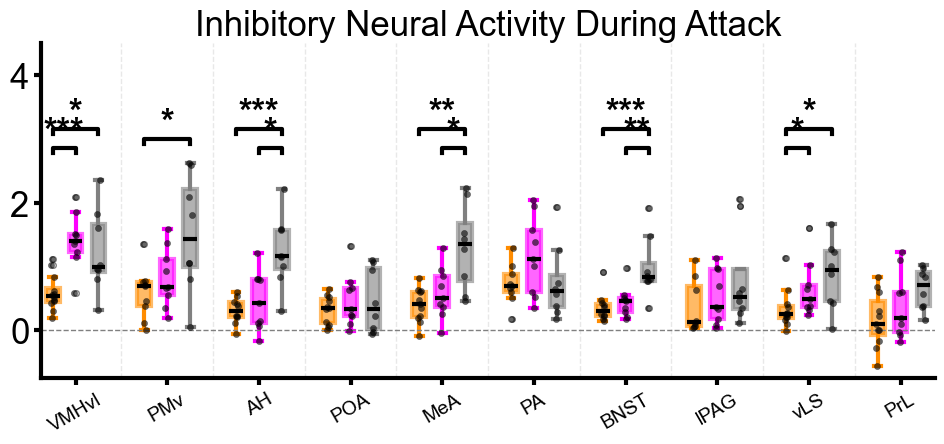

In [29]:
# Plot inhibitory activity

# Inits
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
       'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
       'VMHvl (E)', 'VMHvl (I)', 'lPAG (E)', 'lPAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)', 
       'PA (E)', 'PA (I)', 'NAc (DA)']

def add_significance_brackets(ax, positions, data_to_plot, results, y_offset_factor=0.1, center_height=0.5):
    """
    Add significance brackets above boxplots based on statistical results.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to add brackets to
    positions : list
        x-positions of the boxplots
    data_to_plot : list
        Data for each group to determine y-limits
    results : dict
        Statistical results from run_comprehensive_stats
    y_offset_factor : float
        Factor to determine bracket height above data
    """
    if results is None or 'agg_vs_non' not in results:
        return
    
    # Get max
    max_y = max([np.max(data) for data in data_to_plot])

    # Define significance symbols
    def get_significance_symbol(p_val):
        if p_val <= 0.001:
            return '***'
        elif p_val <= 0.01:
            return '**'
        elif p_val <= 0.05:
            return '*'
        # elif p_val <= 0.1:
        #     return '#'  # trend symbol
        else:
            return 'ns'
    
    # Comparisons: [(group1_idx, group2_idx, result_key)]
    comparisons = [
        (0, 2, 'agg_vs_non'),  # AGG vs NON
        (0, 1, 'agg_vs_obs'),  # AGG vs OBS
        (1, 2, 'obs_vs_non')   # OBS vs NON
    ]
    
    # First, determine which comparisons are significant
    significant_comparisons = []
    for group1_idx, group2_idx, result_key in comparisons:
        if result_key in results:
            p_val = results[result_key]['p_corrected']
            sig_symbol = get_significance_symbol(p_val)
            if sig_symbol != 'ns':
                significant_comparisons.append((group1_idx, group2_idx, result_key, sig_symbol))
    
    # If no significant comparisons, return early
    if not significant_comparisons:
        return
    
    # Model bracket heights around 0.5 as the center point
    n_sig = len(significant_comparisons)
    
    if n_sig == 1:
        bracket_heights = [center_height]
    elif n_sig == 2:
        # Distribute around center: -0.05, +0.05
        bracket_heights = [
            center_height - (center_height * 0.05),  # Below center
            center_height + (center_height * 0.05)   # Above center
        ]
    else:  # n_sig == 3
        # Distribute around center: -0.1, 0, +0.1
        bracket_heights = [
            center_height - (center_height * 0.1),  # Below center
            center_height,                   # At center (0.5)
            center_height + (center_height * 0.1)   # Above center
        ]

    bracket_heights = np.array(bracket_heights) 

    # Sort comparisons by span (distance between groups) to minimize overlap
    # Shorter spans get lower brackets
    significant_comparisons.sort(key=lambda x: abs(positions[x[1]] - positions[x[0]]))
    
    # Draw brackets for significant comparisons
    for i, (group1_idx, group2_idx, result_key, sig_symbol) in enumerate(significant_comparisons):
        x1, x2 = positions[group1_idx], positions[group2_idx]
        bracket_height = bracket_heights[i]
        
        # Get line width from axes to match bracket thickness
        axes_linewidth = ax.spines['bottom'].get_linewidth() - 1
        bracket_linewidth = max(axes_linewidth, 1.5)  # Ensure minimum thickness
        
        # Draw bracket with thicker lines
        bracket_drop = center_height * 0.025  # How much the bracket drops down at the ends
        ax.plot([x1, x1, x2, x2], 
               [bracket_height - bracket_drop, bracket_height, 
                bracket_height, bracket_height - bracket_drop], 
               'k-', linewidth=bracket_linewidth)
        
        # Add significance symbol - positioned closer to bracket
        text_offset = center_height * 0.0001  # Reduced from 0.05 to bring text closer
        ax.text((x1 + x2) / 2, bracket_height + text_offset - 0.01, 
               sig_symbol, ha='center', va='bottom', fontsize=25, fontweight='bold', fontfamily='Arial')

mean_func = np.nanmean
agg_diff = np.transpose(agg_activity, [1, 0])
obs_diff = np.transpose(obs_activity, [1, 0])
non_diff = np.transpose(non_activity, [1, 0])
new_region_ids = [s.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '') for s in region_ids]
idxs2loop = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1])  # only inhibitory
amped_idxs = (np.arange(23) * 4)[:10]
colors = ['darkorange', 'magenta', 'gray']

plt.close()
fig, ax = plt.subplots(figsize=(10, 5))
all_stats_results = []

for r, (roi, roi_amp) in enumerate(zip(idxs2loop, amped_idxs)):
    print(region_ids[roi])

    agg_valid = agg_diff[:, roi][~np.isnan(agg_diff[:, roi])]
    obs_valid = obs_diff[:, roi][~np.isnan(obs_diff[:, roi])]
    non_valid = non_diff[:, roi][~np.isnan(non_diff[:, roi])]

    data_to_plot = [agg_valid, obs_valid, non_valid]

    stats_result = anova_stats(data_to_plot)
    all_stats_results.append(stats_result)

    positions = np.array([roi_amp, roi_amp + 1, roi_amp + 2])

    # ── Boxplots — solid fill, colored edges, BORIS style ──────────────────
    box = ax.boxplot(data_to_plot,
                     positions=positions,
                     patch_artist=True,
                     widths=0.6,
                     medianprops=dict(color='black', linewidth=3),
                     whiskerprops=dict(linewidth=3),
                     capprops=dict(linewidth=3),
                     flierprops=dict(marker='o', markersize=4,
                                     markeredgecolor='black', alpha=0.5))

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.6)
        patch.set_linewidth(3)

    for whisker, color in zip(
        box['whiskers'],
        [c for c in colors for _ in (0, 1)]
    ):
        whisker.set_color(color)

    for cap, color in zip(
        box['caps'],
        [c for c in colors for _ in (0, 1)]
    ):
        cap.set_color(color)

    # ── Individual scatter dots ─────────────────────────────────────────────
    for j, (data, color) in enumerate(zip(data_to_plot, colors)):
        jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter,
                   data, color='black', s=20, alpha=0.6,
                   zorder=5, linewidths=0.3)

    # ── Significance brackets ───────────────────────────────────────────────
    # Remap stats_result posthoc keys to match add_significance_brackets format
    if stats_result['posthoc'] is not None:
        remapped = {
            'agg_vs_non': stats_result['posthoc']['agg_vs_non'],
            'agg_vs_obs': stats_result['posthoc']['agg_vs_obs'],
            'obs_vs_non': stats_result['posthoc']['obs_vs_non'],
        }
    else:
        remapped = None

    add_significance_brackets(ax, positions, data_to_plot,
                               remapped, y_offset_factor=0.15, center_height=3)

# ── Separator lines ─────────────────────────────────────────────────────────
for i in range(len(amped_idxs) - 1):
    separation_x = amped_idxs[i] + 3
    ax.axvline(x=separation_x, color='lightgray', linestyle='--', alpha=0.5, linewidth=1)

# ── Axis formatting ──────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.tick_params(axis='both', length=5, width=3)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(amped_idxs + 1)
ax.set_xticklabels([new_region_ids[i] for i in idxs2loop],
                   rotation=30, fontfamily='Arial', fontsize=14)

for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')

for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.set_ylim(bottom=-0.75, top=4.5)

sns.despine()
ax.set_title('Inhibitory Neural Activity During Attack', fontfamily='Arial', fontsize=25)
plt.tight_layout()
# plt.savefig('.//figures//fig5//HF_inhibitory_activity_boxplots.svg', dpi=600, bbox_inches='tight')
plt.show()

VMHvl (E)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=12, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=True  (Levene p=0.5928, Bartlett p=0.2513)

One-way ANOVA: stat=1.394, p=0.2661

Omnibus not significant — post-hoc tests not run.
###
PMv (E)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=9, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=True  (Levene p=0.4941, Bartlett p=0.5363)

One-way ANOVA: stat=2.256, p=0.1275

Omnibus not significant — post-hoc tests not run.
###
AH (E)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=10, OBS=9, NON=8

Normality: agg=pass, obs=fail, non=pass
Variance: equal=True  (Levene p=0.0947)

Kruskal-Wallis H-test: stat=0.600, p=0.7408

Omnibus not significant — post-hoc tests not run.
###
POA (E)
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample siz

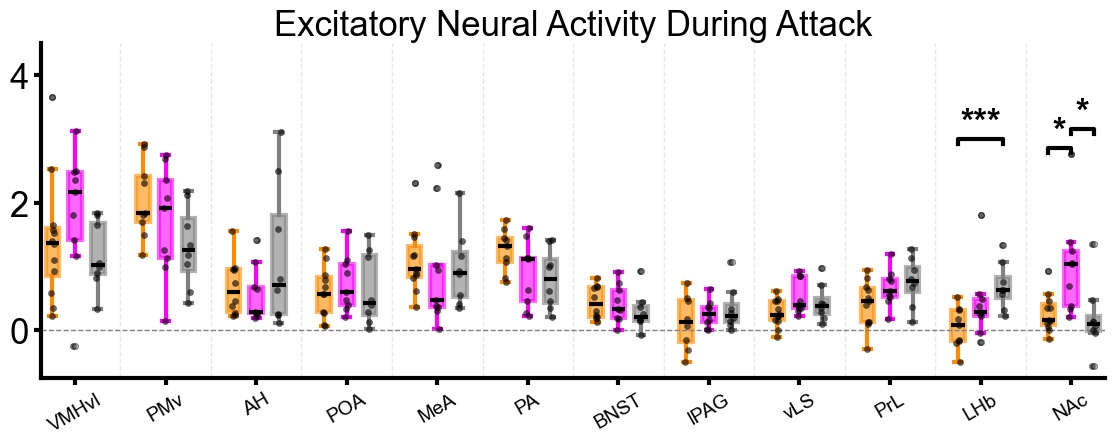

In [30]:
# Plot excitatory activity

mean_func = np.nanmean
agg_diff = np.transpose(agg_activity, [1, 0])
obs_diff = np.transpose(obs_activity, [1, 0])
non_diff = np.transpose(non_activity, [1, 0])
new_region_ids = [s.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '') for s in region_ids]
idxs2loop = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 19, 23])-1
amped_idxs = (np.arange(23)*4)[:12]
colors = ['darkorange', 'magenta', 'gray']

plt.close()
fig, ax = plt.subplots(figsize=(11.7, 5))
all_stats_results = []

for r, (roi, roi_amp) in enumerate(zip(idxs2loop, amped_idxs)):
    print(region_ids[roi])

    agg_valid = agg_diff[:, roi][~np.isnan(agg_diff[:, roi])]
    obs_valid = obs_diff[:, roi][~np.isnan(obs_diff[:, roi])]
    non_valid = non_diff[:, roi][~np.isnan(non_diff[:, roi])]

    data_to_plot = [agg_valid, obs_valid, non_valid]

    stats_result = anova_stats(data_to_plot)
    all_stats_results.append(stats_result)

    positions = np.array([roi_amp, roi_amp + 1, roi_amp + 2])

    # ── Boxplots — solid fill, colored edges, BORIS style ──────────────────
    box = ax.boxplot(data_to_plot,
                     positions=positions,
                     patch_artist=True,
                     widths=0.6,
                     medianprops=dict(color='black', linewidth=3),
                     whiskerprops=dict(linewidth=3),
                     capprops=dict(linewidth=3),
                     flierprops=dict(marker='o', markersize=4,
                                     markeredgecolor='black', alpha=0.5))

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.6)
        patch.set_linewidth(3)

    for whisker, color in zip(
        box['whiskers'],
        [c for c in colors for _ in (0, 1)]
    ):
        whisker.set_color(color)

    for cap, color in zip(
        box['caps'],
        [c for c in colors for _ in (0, 1)]
    ):
        cap.set_color(color)

    # ── Individual scatter dots ─────────────────────────────────────────────
    for j, (data, color) in enumerate(zip(data_to_plot, colors)):
        jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter,
                   data, color='black', s=20, alpha=0.6,
                   zorder=5, linewidths=0.3)

    # ── Significance brackets ───────────────────────────────────────────────
    # Remap stats_result posthoc keys to match add_significance_brackets format
    if stats_result['posthoc'] is not None:
        remapped = {
            'agg_vs_non': stats_result['posthoc']['agg_vs_non'],
            'agg_vs_obs': stats_result['posthoc']['agg_vs_obs'],
            'obs_vs_non': stats_result['posthoc']['obs_vs_non'],
        }
    else:
        remapped = None

    add_significance_brackets(ax, positions, data_to_plot,
                               remapped, y_offset_factor=0.15, center_height=3)

# ── Separator lines ─────────────────────────────────────────────────────────
for i in range(len(amped_idxs) - 1):
    separation_x = amped_idxs[i] + 3
    ax.axvline(x=separation_x, color='lightgray', linestyle='--', alpha=0.5, linewidth=1)


# ── Axis formatting ──────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.tick_params(axis='both', length=5, width=3)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(amped_idxs + 1)
ax.set_xticklabels([new_region_ids[i] for i in idxs2loop],
                   rotation=30, fontfamily='Arial', fontsize=14)

for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')

for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.set_ylim(bottom=-0.75, top=4.5)

sns.despine()
ax.set_title('Excitatory Neural Activity During Attack', fontfamily='Arial', fontsize=25)
plt.tight_layout()
# plt.savefig('.//figures//fig5//HF_excitatory_activity_boxplots.svg', dpi=600, bbox_inches='tight')
plt.show()

In [32]:
# ── Source data export: 5a ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

def build_5a_source(agg_diff, obs_diff, non_diff, idxs2loop, region_ids, channel_label):
    rows = []
    for roi in idxs2loop:
        region_label = region_ids[roi].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        agg_valid = agg_diff[:, roi][~np.isnan(agg_diff[:, roi])]
        obs_valid = obs_diff[:, roi][~np.isnan(obs_diff[:, roi])]
        non_valid = non_diff[:, roi][~np.isnan(non_diff[:, roi])]

        stats_result = anova_stats([agg_valid, obs_valid, non_valid])
        omni = stats_result['omnibus']
        ph = stats_result['posthoc']  # None if omnibus not significant

        for group_label, vals in [('EXP', agg_valid), ('OBS', obs_valid), ('NON', non_valid)]:
            for v in vals:
                row = {
                    'channel': channel_label,
                    'region': region_label,
                    'group': group_label,
                    'value': v,
                    'omnibus_test': omni['test_type'],
                    'omnibus_stat': omni['statistic'],
                    'omnibus_p': omni['p_value'],
                    'pairwise_test': stats_result['pairwise_test'],
                }
                for comp in ['agg_vs_non', 'agg_vs_obs', 'obs_vs_non']:
                    if ph is not None:
                        row[f'{comp}_stat']   = ph[comp]['statistic']
                        row[f'{comp}_df']     = ph[comp]['df']
                        row[f'{comp}_p_raw']  = ph[comp]['p_value']
                        row[f'{comp}_p_fdr']  = ph[comp]['p_corrected']
                    else:
                        row[f'{comp}_stat']   = np.nan
                        row[f'{comp}_df']     = np.nan
                        row[f'{comp}_p_raw']  = np.nan
                        row[f'{comp}_p_fdr']  = np.nan
                rows.append(row)
    return rows

idxs2loop_I = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1])
idxs2loop_E = np.array([13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 19, 23]) - 1

rows_I = build_5a_source(agg_diff, obs_diff, non_diff, idxs2loop_I, region_ids, 'I')
rows_E = build_5a_source(agg_diff, obs_diff, non_diff, idxs2loop_E, region_ids, 'E')

sourceData_5a = pd.DataFrame(rows_I + rows_E)
sourceData_5a.to_csv('./sourceData/5a.csv', index=False)

=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=12, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=False  (Levene p=0.1844, Bartlett p=0.0446)

One-way ANOVA: stat=9.691, p=0.0007

Post-hoc comparisons (t-test, FDR corrected):
  AGG_VS_NON: stat=-3.060, df=18.0, p_corr=0.0101 *
  AGG_VS_OBS: stat=-5.335, df=19.0, p_corr=0.0001 ***
  OBS_VS_NON: stat=0.665, df=15.0, p_corr=0.5160 ns
###
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=9, OBS=9, NON=8

Normality: agg=pass, obs=pass, non=pass
Variance: equal=False  (Levene p=0.0181, Bartlett p=0.0555)

One-way ANOVA: stat=5.027, p=0.0154

Post-hoc comparisons (t-test, FDR corrected):
  AGG_VS_NON: stat=-2.771, df=15.0, p_corr=0.0428 *
  AGG_VS_OBS: stat=-1.181, df=16.0, p_corr=0.2548 ns
  OBS_VS_NON: stat=-1.989, df=15.0, p_corr=0.0979 ns
###
=== ANOVA/KW ANALYSIS (normality -> variance -> omnibus -> posthoc) ===
Sample sizes: AGG=10,

### Group classification based on neural activity

In [11]:
# ── Build train/test arrays ────────────────────────────────────────────────────
# aggression_related_activity shape: (n_rois, n_animals)
# agg_activity  : (n_rois, 12)  — EXP animals
# obs_activity  : (n_rois, 9)   — OBS animals (held out)
# non_activity  : (n_rois, 8)   — NON animals

def get_sig(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# X: (n_animals, n_rois) — transpose so animals are rows
X_train = np.concatenate([agg_activity, non_activity], axis=1).T  # (20, n_rois)
X_obs   = obs_activity.T                                           # (9,  n_rois)

# y: 1=EXP, 0=NON
y_train = np.array([1]*agg_activity.shape[1] +
                   [0]*non_activity.shape[1])                      # (20,)

print(f'X_train : {X_train.shape}  (EXP={agg_activity.shape[1]}  NON={non_activity.shape[1]})')
print(f'X_obs   : {X_obs.shape}')
print(f'y_train : {y_train.shape}  (1s={y_train.sum()}  0s={(y_train==0).sum()})')
print(f'NaN fraction — train: {np.isnan(X_train).mean():.3f}  '
      f'obs: {np.isnan(X_obs).mean():.3f}')

X_train : (20, 23)  (EXP=12  NON=8)
X_obs   : (9, 23)
y_train : (20,)  (1s=12  0s=8)
NaN fraction — train: 0.089  obs: 0.000


In [15]:
# Run LDA classifiers

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import permutation_test_score, LeaveOneOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import shapiro, levene, bartlett, ttest_ind, brunnermunzel

inh_idx = np.array([1, 3, 5, 7, 9, 11, 13, 15, 17, 21])
exc_idx = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 20])

subsets = {
    'Full':        np.concatenate((exc_idx, inh_idx)),
    'Inhibitory':  inh_idx,
    'Excitatory':  exc_idx,
}

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else 0


def run_pairwise_stats(a, b, alternative='two-sided', alpha=0.05, variance_alpha=0.05):
    """
    Two-sample comparison, no omnibus (only 2 groups):
    1) Normality (Shapiro, both groups)
    2) Variance (Levene always; Bartlett too if both normal)
    3) Test selection: t-test (normal+equal var) / Welch t-test
       (normal+unequal var) / Brunner-Munzel (non-normal)
    Returns dict: test, statistic, df, p_value, normality_ps, levene_p.
    """
    if len(a) < 3 or len(b) < 3:
        return {'test': 'n/a', 'statistic': np.nan, 'df': np.nan, 'p_value': np.nan,
                'normality_ps': (np.nan, np.nan), 'levene_p': np.nan}

    _, p_norm_a = shapiro(a)
    _, p_norm_b = shapiro(b)
    normality_passed = (p_norm_a > alpha) and (p_norm_b > alpha)

    levene_stat, levene_p = levene(a, b)
    equal_variances = levene_p > variance_alpha
    if normality_passed:
        _, bartlett_p = bartlett(a, b)
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    if normality_passed and equal_variances:
        stat, p = ttest_ind(a, b, equal_var=True, alternative=alternative)
        test_name = 't-test'
        df = len(a) + len(b) - 2
    elif normality_passed and not equal_variances:
        stat, p = ttest_ind(a, b, equal_var=False, alternative=alternative)
        test_name = 'Welch t-test'
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        stat, p = brunnermunzel(a, b, alternative=alternative)
        test_name = 'Brunner-Munzel'
        df = np.nan

    return {'test': test_name, 'statistic': stat, 'df': df, 'p_value': p,
            'normality_ps': (p_norm_a, p_norm_b), 'levene_p': levene_p}

results_by_subset = {}

for name, idx in subsets.items():
    print(f'\n{"="*55}\n{name}  ({len(idx)} regions)\n{"="*55}')

    X_tr = X_train[:, idx]
    X_ob = X_obs[:,   idx]

    imp    = SimpleImputer(strategy='mean')
    X_tr   = imp.fit_transform(X_tr)
    X_ob   = imp.transform(X_ob)

    sc     = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_ob_s = sc.transform(X_ob)

    lda_sub = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
    lda_sub.fit(X_tr_s, y_train)

    score_sub, perm_sub, p_sub = permutation_test_score(
        lda_sub, X_tr_s, y_train,
        cv=LeaveOneOut(), scoring='balanced_accuracy',
        n_permutations=1000, random_state=42, n_jobs=-1
    )
    print(f'LOO acc={score_sub:.3f}  perm p={p_sub:.4f}')

    exp_p = lda_sub.transform(X_tr_s[y_train==1]).ravel()
    non_p = lda_sub.transform(X_tr_s[y_train==0]).ravel()
    obs_p = lda_sub.transform(X_ob_s).ravel()

    if np.mean(exp_p) > np.mean(non_p):
        exp_p, non_p, obs_p = -exp_p, -non_p, -obs_p

    stats_obs_non = run_pairwise_stats(obs_p, non_p)
    stats_obs_exp = run_pairwise_stats(obs_p, exp_p)
    p_obs_non = stats_obs_non['p_value']
    p_obs_exp = stats_obs_exp['p_value']
    def _df_str(d):
        return f'{d:.1f}' if not np.isnan(d) else 'n/a'

    print(f'OBS vs NON: {stats_obs_non["test"]} stat={stats_obs_non["statistic"]:.3f} '
          f'df={_df_str(stats_obs_non["df"])} '
          f'p={p_obs_non:.4f}')
    print(f'OBS vs EXP: {stats_obs_exp["test"]} stat={stats_obs_exp["statistic"]:.3f} '
          f'df={_df_str(stats_obs_exp["df"])} '
          f'p={p_obs_exp:.4f}')

    full_d             = cohens_d(obs_p, non_p)
    full_obs_mean      = np.mean(obs_p)
    full_exp_mean      = np.mean(exp_p)
    full_non_mean      = np.mean(non_p)
    full_obs_normalized = (full_obs_mean - full_exp_mean) / \
                          (full_non_mean - full_exp_mean)

    # ── LOPO  ──────────────────────────────────────────────────
    lopo_results = []
    for drop_pos, drop_ri in enumerate(idx):
        remaining = np.delete(idx, drop_pos)
        if len(remaining) < 2:
            continue

        X_tr_d  = X_train[:, remaining]
        X_ob_d  = X_obs[:,   remaining]

        imp_d   = SimpleImputer(strategy='mean')
        X_tr_d  = imp_d.fit_transform(X_tr_d)
        X_ob_d  = imp_d.transform(X_ob_d)

        sc_d    = StandardScaler()
        X_tr_ds = sc_d.fit_transform(X_tr_d)
        X_ob_ds = sc_d.transform(X_ob_d)

        lda_d = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
        lda_d.fit(X_tr_ds, y_train)

        exp_d = lda_d.transform(X_tr_ds[y_train==1]).ravel()
        non_d = lda_d.transform(X_tr_ds[y_train==0]).ravel()
        obs_d = lda_d.transform(X_ob_ds).ravel()

        if np.mean(exp_d) > np.mean(non_d):
            exp_d, non_d, obs_d = -exp_d, -non_d, -obs_d

        drop_stats = run_pairwise_stats(obs_d, non_d)
        p_drop     = drop_stats['p_value']
        drop_d     = cohens_d(obs_d, non_d)

        # normalized OBS position: EXP=0, NON=1
        denom = np.mean(non_d) - np.mean(exp_d)
        if abs(denom) > 1e-6:
            obs_norm_drop  = (np.mean(obs_d) - np.mean(exp_d)) / denom
            delta_obs_pos  = obs_norm_drop - full_obs_normalized
        else:
            delta_obs_pos  = np.nan

        lopo_results.append({
            'region':         region_ids[drop_ri],
            'region_idx':     drop_ri,
            'delta_cohens_d': full_d - drop_d,       # + = dropping hurt separation
            'delta_obs_pos':  delta_obs_pos,          # + = OBS shifted toward NON
            'p_obs_non':      p_drop,
            'test_obs_non':   drop_stats['test'],
        })
        print(f'  drop {region_ids[drop_ri]:<22} '
              f'Δd={full_d - drop_d:+.3f}  '
              f'ΔOBS_pos={delta_obs_pos:+.3f}  '
              f'{drop_stats["test"]}: p(OBS-NON)={p_drop:.4f}')

    results_by_subset[name] = {
        'lda':          lda_sub,
        'score':        score_sub,
        'perm_p':       p_sub,
        'perm_scores':  perm_sub,
        'exp_proj':     exp_p,
        'obs_proj':     obs_p,
        'non_proj':     non_p,
        'p_obs_non':    p_obs_non,
        'p_obs_exp':    p_obs_exp,
        'stats_obs_non': stats_obs_non,
        'stats_obs_exp': stats_obs_exp,
        'idx':          idx,
        'lopo':         lopo_results,
    }


Full  (20 regions)


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single 

LOO acc=0.900  perm p=0.0020
OBS vs NON: t-test stat=-4.567 df=15.0 p=0.0004
OBS vs EXP: t-test stat=3.068 df=19.0 p=0.0063
  drop PrL (E)                Δd=+0.020  ΔOBS_pos=-0.006  t-test: p(OBS-NON)=0.0003
  drop vLS (E)                Δd=+0.019  ΔOBS_pos=-0.004  t-test: p(OBS-NON)=0.0003
  drop POA (E)                Δd=-0.019  ΔOBS_pos=+0.001  t-test: p(OBS-NON)=0.0004
  drop BNST (E)               Δd=-0.141  ΔOBS_pos=-0.019  t-test: p(OBS-NON)=0.0006
  drop AH (E)                 Δd=-0.025  ΔOBS_pos=-0.004  t-test: p(OBS-NON)=0.0004
  drop MeA (E)                Δd=-0.019  ΔOBS_pos=-0.010  t-test: p(OBS-NON)=0.0004
  drop VMHvl (E)              Δd=-0.054  ΔOBS_pos=+0.014  t-test: p(OBS-NON)=0.0004
  drop lPAG (E)               Δd=-0.003  ΔOBS_pos=+0.002  t-test: p(OBS-NON)=0.0004
  drop PMv (E)                Δd=+0.087  ΔOBS_pos=-0.019  t-test: p(OBS-NON)=0.0002
  drop PA (E)                 Δd=+0.100  ΔOBS_pos=-0.034  t-test: p(OBS-NON)=0.0002
  drop PrL (I)                Δd=-0.

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single 

LOO acc=0.900  perm p=0.0010
OBS vs NON: t-test stat=-3.252 df=15.0 p=0.0054
OBS vs EXP: t-test stat=2.321 df=19.0 p=0.0315
  drop PrL (I)                Δd=-0.046  ΔOBS_pos=-0.020  t-test: p(OBS-NON)=0.0062
  drop vLS (I)                Δd=-0.016  ΔOBS_pos=-0.018  t-test: p(OBS-NON)=0.0058
  drop POA (I)                Δd=+0.066  ΔOBS_pos=-0.013  t-test: p(OBS-NON)=0.0041
  drop BNST (I)               Δd=-0.143  ΔOBS_pos=+0.056  t-test: p(OBS-NON)=0.0094
  drop AH (I)                 Δd=-0.269  ΔOBS_pos=+0.070  t-test: p(OBS-NON)=0.0155
  drop MeA (I)                Δd=-0.248  ΔOBS_pos=+0.057  t-test: p(OBS-NON)=0.0145
  drop VMHvl (I)              Δd=+0.148  ΔOBS_pos=-0.088  t-test: p(OBS-NON)=0.0030
  drop lPAG (I)               Δd=+0.038  ΔOBS_pos=-0.001  t-test: p(OBS-NON)=0.0046
  drop PMv (I)                Δd=-0.145  ΔOBS_pos=+0.054  t-test: p(OBS-NON)=0.0095
  drop PA (I)                 Δd=-0.124  ΔOBS_pos=+0.033  t-test: p(OBS-NON)=0.0087

Excitatory  (10 regions)


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single 

LOO acc=0.700  perm p=0.0989
OBS vs NON: Welch t-test stat=-1.797 df=11.2 p=0.0992
OBS vs EXP: Welch t-test stat=2.463 df=10.8 p=0.0318
  drop PrL (E)                Δd=-0.097  ΔOBS_pos=-0.035  Welch t-test: p(OBS-NON)=0.1363
  drop vLS (E)                Δd=+0.169  ΔOBS_pos=-0.088  Welch t-test: p(OBS-NON)=0.0557
  drop POA (E)                Δd=-0.084  ΔOBS_pos=-0.003  t-test: p(OBS-NON)=0.1384
  drop BNST (E)               Δd=-0.139  ΔOBS_pos=+0.005  Brunner-Munzel: p(OBS-NON)=0.2717
  drop AH (E)                 Δd=-0.291  ΔOBS_pos=+0.101  t-test: p(OBS-NON)=0.2581
  drop MeA (E)                Δd=+0.036  ΔOBS_pos=-0.008  Welch t-test: p(OBS-NON)=0.0876
  drop VMHvl (E)              Δd=-0.028  ΔOBS_pos=+0.002  Brunner-Munzel: p(OBS-NON)=0.2559
  drop lPAG (E)               Δd=-0.022  ΔOBS_pos=+0.012  Welch t-test: p(OBS-NON)=0.1067
  drop PMv (E)                Δd=-0.116  ΔOBS_pos=+0.012  t-test: p(OBS-NON)=0.1527
  drop PA (E)                 Δd=+0.129  ΔOBS_pos=-0.048  Welch t-te


── Bonferroni-corrected p-values (Full + Inhibitory only) ──
  Full            obs_non    raw=0.0004  fdr=0.0015  **
  Full            obs_exp    raw=0.0063  fdr=0.0253  *
  Inhibitory      obs_non    raw=0.0054  fdr=0.0214  *
  Inhibitory      obs_exp    raw=0.0315  fdr=0.1262  


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\325191558.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['EXP', 'OBS', 'NON'], fontfamily='Arial', fontsize=11)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38952\325191558.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['EXP', 'OBS', 'NON'], fontfamily='Arial', fontsize=11)


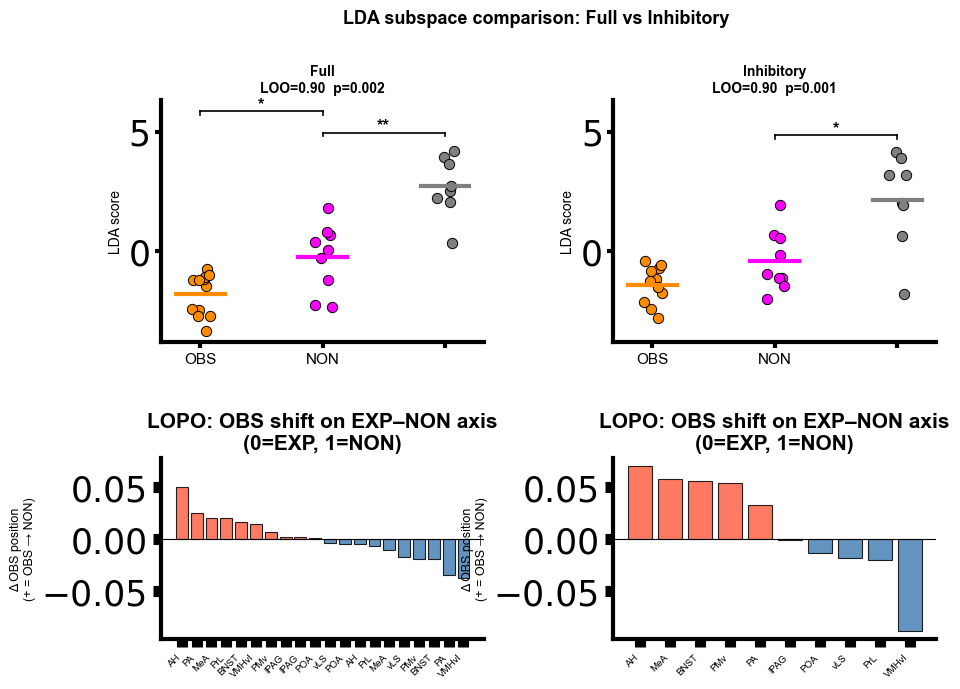

In [16]:
# Plots
subsets_for_correction = ['Full', 'Inhibitory']
subsets_to_plot = ['Full', 'Inhibitory']  # Excitatory dropped entirely

all_pval_keys = []
all_pvals     = []

for name in subsets_to_plot:
    res = results_by_subset[name]
    all_pval_keys.append((name, 'obs_non'))
    all_pvals.append(res['p_obs_non'])
    all_pval_keys.append((name, 'obs_exp'))
    all_pvals.append(res['p_obs_exp'])

_, all_pvals_fdr, _, _ = multipletests(all_pvals, method='bonferroni')
pval_fdr_lookup = {k: p for k, p in zip(all_pval_keys, all_pvals_fdr)}

print('\n── Bonferroni-corrected p-values (Full + Inhibitory only) ──')
for k, p_raw, p_fdr in zip(all_pval_keys, all_pvals, all_pvals_fdr):
    sig = get_sig(p_fdr)
    print(f'  {k[0]:<15} {k[1]:<10} raw={p_raw:.4f}  fdr={p_fdr:.4f}  {sig}')

n_subsets = len(subsets_to_plot)
fig = plt.figure(figsize=(5 * n_subsets, 7))
gs  = fig.add_gridspec(2, n_subsets, height_ratios=[2, 1.5], hspace=0.55, wspace=0.4)

for col, name in enumerate(subsets_to_plot):
    res   = results_by_subset[name]
    exp_p = res['exp_proj']
    obs_p = res['obs_proj']
    non_p = res['non_proj']
    lopo  = res['lopo']

    # ── Row 0: LDA strip plot ─────────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, col])
    for label, data, color in [
        ('EXP', exp_p, 'darkorange'),
        ('OBS', obs_p, 'magenta'),
        ('NON', non_p, 'gray'),
    ]:
        xp     = {'EXP': 0, 'OBS': 1, 'NON': 2}[label]
        jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(data))
        ax0.scatter(xp + jitter, data, color=color, s=55,
                    edgecolors='black', linewidths=0.7, zorder=3)
        ax0.plot([xp-0.2, xp+0.2], [np.mean(data)]*2,
                 color=color, linewidth=3, zorder=4)

    y_max = max(exp_p.max(), obs_p.max(), non_p.max())
    y_min = min(exp_p.min(), obs_p.min(), non_p.min())
    step  = (y_max - y_min) * 0.10

    def bracket(ax, x1, x2, y, p):
        sig = get_sig(p)
        if not sig: return
        ax.plot([x1, x2], [y, y], 'k-', linewidth=1.2)
        ax.plot([x1, x1], [y - step*0.2, y], 'k-', linewidth=1.2)
        ax.plot([x2, x2], [y - step*0.2, y], 'k-', linewidth=1.2)
        ax.text((x1+x2)/2, y, sig, ha='center', va='bottom',
                fontsize=12, fontweight='bold', fontfamily='Arial')

    bracket(ax0, 1, 2, y_max + step, pval_fdr_lookup[(name, 'obs_non')])
    bracket(ax0, 0, 1, y_max + step * 2.2, pval_fdr_lookup[(name, 'obs_exp')])
    ax0.set_xticklabels(['EXP', 'OBS', 'NON'], fontfamily='Arial', fontsize=11)
    ax0.set_ylabel('LDA score', fontfamily='Arial', fontsize=10)
    ax0.set_title(f'{name}\nLOO={res["score"]:.2f}  p={res["perm_p"]:.3f}',
                  fontfamily='Arial', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values(): spine.set_linewidth(3)
    ax0.tick_params(width=3, length=4)
    sns.despine(ax=ax0)

    if not lopo:
        continue

    lopo_sorted = sorted(lopo, key=lambda x: x['delta_obs_pos']
                          if not np.isnan(x['delta_obs_pos']) else -999,
                          reverse=True)
    clean_names = [r['region'].replace(' (E)','').replace(' (I)','')
                               .replace(' (DA)','') for r in lopo_sorted]
    xpos = np.arange(len(lopo_sorted))

    # ── Row 1: Δ OBS normalized position (Cohen's d row removed) ─────────────
    ax2 = fig.add_subplot(gs[1, col])
    vals2 = np.array([r['delta_obs_pos']
                       if not np.isnan(r['delta_obs_pos']) else 0
                       for r in lopo_sorted])
    colors_bar2 = ['tomato' if v > 0 else 'steelblue' for v in vals2]
    ax2.bar(xpos, vals2, color=colors_bar2, edgecolor='black',
            linewidth=0.8, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xticks(xpos)
    ax2.set_xticklabels(clean_names, rotation=45, ha='right',
                        fontsize=7, fontfamily='Arial')
    ax2.set_ylabel('Δ OBS position\n(+ = OBS → NON)', fontsize=9,
                   fontfamily='Arial')
    ax2.set_title('LOPO: OBS shift on EXP–NON axis\n(0=EXP, 1=NON)',
                  fontsize=15, fontweight='bold', fontfamily='Arial')
    for spine in ax2.spines.values(): spine.set_linewidth(3)
    sns.despine(ax=ax2)

for row_axes in [
    [fig.axes[i*2]     for i in range(n_subsets)],   # row 0: LDA scores
    [fig.axes[i*2 + 1] for i in range(n_subsets)],   # row 1: OBS position
]:
    valid = [ax for ax in row_axes if ax.get_visible()]
    if not valid:
        continue
    y_min = min(ax.get_ylim()[0] for ax in valid)
    y_max = max(ax.get_ylim()[1] for ax in valid)
    for ax in valid:
        ax.set_ylim(y_min, y_max)

plt.suptitle('LDA subspace comparison: Full vs Inhibitory',
             fontsize=13, fontweight='bold', fontfamily='Arial', y=1.01)
# plt.savefig('./figures/fig5/lda_subspace_lopo.svg', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
rows = []
for name in ['Full', 'Inhibitory']:
    res = results_by_subset[name]
    for group_label, vals in [('EXP', res['exp_proj']), ('OBS', res['obs_proj']), ('NON', res['non_proj'])]:
        for v in vals:
            rows.append({
                'model': name,
                'group': group_label,
                'lda_score': v,
                'loo_accuracy': res['score'],
                'loo_perm_p': res['perm_p'],
                'p_obs_non_raw': res['p_obs_non'],
                'p_obs_non_fdr': pval_fdr_lookup[(name, 'obs_non')],
                'p_obs_exp_raw': res['p_obs_exp'],
                'p_obs_exp_fdr': pval_fdr_lookup[(name, 'obs_exp')],
            })

sourceData_5e = pd.DataFrame(rows)
sourceData_5e.to_csv('./sourceData/5e.csv', index=False)

In [ ]:
lopo_inh = results_by_subset['Inhibitory']['lopo']

sourceData_5f = pd.DataFrame([
    {
        'region': r['region'].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''),
        'region_idx': r['region_idx'],
        'delta_obs_position': r['delta_obs_pos'],
    }
    for r in lopo_inh
])

sourceData_5f.to_csv('./sourceData/5f.csv', index=False)

In [24]:
print('\n── Full stats summary ──')
print(f'  {"Subset":<15} {"Comparison":<12} {"t-stat":>10} '
      f'{"p_raw":>10} {"p_bonf":>10} {"Sig":>5} '
      f'{"n1":>5} {"n2":>5}')
print(f'  {"─"*75}')

for k, p_raw, p_fdr in zip(all_pval_keys, all_pvals, all_pvals_fdr):
    name, comparison = k
    res = results_by_subset[name]

    if comparison == 'obs_non':
        a, b   = res['obs_proj'], res['non_proj']
        label1, label2 = 'OBS', 'NON'
    else:
        a, b   = res['obs_proj'], res['exp_proj']
        label1, label2 = 'OBS', 'EXP'

    u_stat, _ = ttest_ind(a, b, alternative='two-sided')
    sig        = get_sig(p_fdr)

    print(f'  {name:<15} {label1} vs {label2:<8} {u_stat:>10.3f} '
          f'{p_raw:>10.4f} {p_fdr:>10.4f} {sig:>5} '
          f'{len(a):>5} {len(b):>5}')

print(f'  {"─"*75}')

# ── Per-subset decoder summary (Full + Inhibitory only) ──────────────────────
print(f'\n── Decoder summary ──')
print(f'  {"Subset":<15} {"LOO acc":>9} {"perm p":>9} '
      f'{"n_perms":>9} {"n_EXP":>7} {"n_NON":>7} {"n_OBS":>7}')
print(f'  {"─"*70}')

for name, res in results_by_subset.items():
    if name not in subsets_for_correction:
        continue
    n_exp  = int((y_train == 1).sum())
    n_non  = int((y_train == 0).sum())
    n_obs  = len(res['obs_proj'])
    n_perm = len(res['perm_scores']) if 'perm_scores' in res else 1000
    print(f'  {name:<15} {res["score"]:>9.3f} {res["perm_p"]:>9.4f} '
          f'{n_perm:>9} {n_exp:>7} {n_non:>7} {n_obs:>7}')

print(f'  {"─"*70}')

# ── Permutation null CI per subset (Full + Inhibitory only) ──────────────────
print(f'\n── Permutation null 95% CI ──')
print(f'  {"Subset":<15} {"null_mean":>10} {"CI_low":>10} {"CI_high":>10} '
      f'{"observed":>10}')
print(f'  {"─"*55}')

for name, res in results_by_subset.items():
    if name not in subsets_for_correction:
        continue
    if 'perm_scores' in res:
        null     = res['perm_scores']
        ci_low   = np.percentile(null, 2.5)
        ci_high  = np.percentile(null, 97.5)
        print(f'  {name:<15} {np.mean(null):>10.3f} '
              f'{ci_low:>10.3f} {ci_high:>10.3f} '
              f'{res["score"]:>10.3f}')

print(f'  {"─"*55}')


── Full stats summary ──
  Subset          Comparison       t-stat      p_raw     p_bonf   Sig    n1    n2
  ───────────────────────────────────────────────────────────────────────────
  Full            OBS vs NON          -4.567     0.0004     0.0015    **     9     8
  Full            OBS vs EXP           3.068     0.0063     0.0253     *     9    12
  Inhibitory      OBS vs NON          -3.252     0.0054     0.0214     *     9     8
  Inhibitory      OBS vs EXP           2.321     0.0315     0.1262           9    12
  ───────────────────────────────────────────────────────────────────────────

── Decoder summary ──
  Subset            LOO acc    perm p   n_perms   n_EXP   n_NON   n_OBS
  ──────────────────────────────────────────────────────────────────────
  Full                0.900    0.0020      1000      12       8       9
  Inhibitory          0.900    0.0010      1000      12       8       9
  ──────────────────────────────────────────────────────────────────────

── Permuta

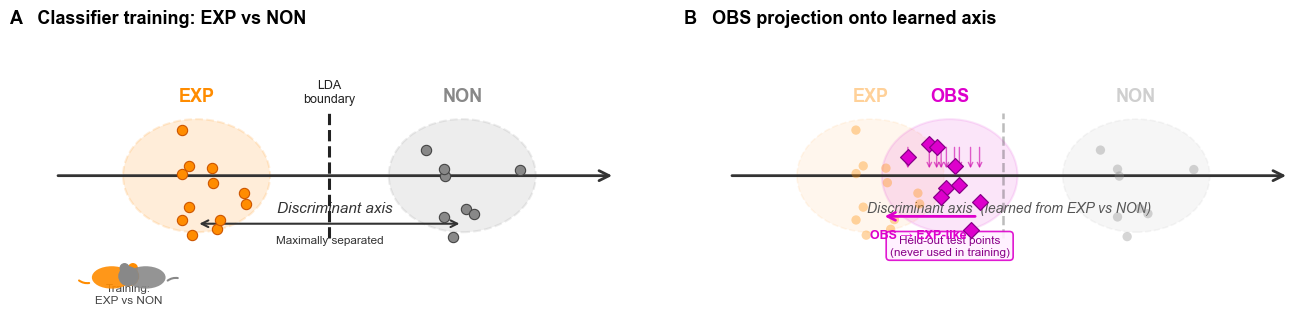

In [130]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ── shared axis style ─────────────────────────────────────────────────────────
def style_ax(ax):
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1.2, 3.8)
    ax.set_aspect('equal')
    ax.axis('off')

# ══════════════════════════════════════════════════════════════════════════════
# PANEL A — Training: EXP vs NON classifier
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[0]
style_ax(ax)

# ── discriminant axis ─────────────────────────────────────────────────────────
axis_y   = 1.3
axis_x0  = 0.3
axis_x1  = 10.2

ax.annotate('', xy=(axis_x1, axis_y), xytext=(axis_x0, axis_y),
            arrowprops=dict(arrowstyle='->', color='#333333',
                            lw=2.0, mutation_scale=18))
ax.text((axis_x0 + axis_x1)/2, axis_y - 0.45,
        'Discriminant axis', ha='center', va='top',
        fontsize=11, fontfamily='Arial', color='#333333', style='italic')

# ── EXP cluster (left) ────────────────────────────────────────────────────────
exp_cx, exp_cy = 2.8, 1.3
exp_pts_x = exp_cx + np.random.randn(12) * 0.55
exp_pts_y = exp_cy + np.random.randn(12) * 0.55

ell_exp = Ellipse((exp_cx, exp_cy), width=2.6, height=2.0,
                  angle=0, facecolor='#FF8C00', alpha=0.15,
                  edgecolor='#FF8C00', linewidth=1.5, linestyle='--')
ax.add_patch(ell_exp)
ax.scatter(exp_pts_x, exp_pts_y, color='#FF8C00', s=55,
           edgecolors='#CC5500', linewidths=0.8, zorder=4)
ax.text(exp_cx, exp_cy + 1.25, 'EXP', ha='center', va='bottom',
        fontsize=13, fontweight='bold', fontfamily='Arial',
        color='#FF8C00')

# ── NON cluster (right) ───────────────────────────────────────────────────────
non_cx, non_cy = 7.5, 1.3
non_pts_x = non_cx + np.random.randn(8) * 0.55
non_pts_y = non_cy + np.random.randn(8) * 0.55

ell_non = Ellipse((non_cx, non_cy), width=2.6, height=2.0,
                  angle=0, facecolor='#888888', alpha=0.15,
                  edgecolor='#888888', linewidth=1.5, linestyle='--')
ax.add_patch(ell_non)
ax.scatter(non_pts_x, non_pts_y, color='#888888', s=55,
           edgecolors='#444444', linewidths=0.8, zorder=4)
ax.text(non_cx, non_cy + 1.25, 'NON', ha='center', va='bottom',
        fontsize=13, fontweight='bold', fontfamily='Arial',
        color='#888888')

# ── LDA boundary ──────────────────────────────────────────────────────────────
boundary_x = (exp_cx + non_cx) / 2
ax.plot([boundary_x, boundary_x],
        [axis_y - 1.1, axis_y + 1.1],
        color='#222222', linewidth=2.2,
        linestyle='--', zorder=5)
ax.text(boundary_x, axis_y + 1.25, 'LDA\nboundary',
        ha='center', va='bottom', fontsize=9,
        fontfamily='Arial', color='#222222')

# ── small mouse icons (simplified circles + tail) ─────────────────────────────
def draw_mouse(ax, cx, cy, color, direction=1, scale=0.22):
    """Minimal mouse schematic: body ellipse + head circle + ear + tail."""
    body = Ellipse((cx, cy), width=scale*3.2, height=scale*1.8,
                   facecolor=color, edgecolor='none', alpha=0.9, zorder=6)
    ax.add_patch(body)
    hx = cx + direction * scale * 1.4
    head = plt.Circle((hx, cy + scale*0.1), scale*0.75,
                       color=color, zorder=6)
    ax.add_patch(head)
    # ear
    ear = plt.Circle((hx + direction*scale*0.3, cy + scale*0.75),
                      scale*0.35, color=color, zorder=6)
    ax.add_patch(ear)
    # tail
    tail_x = cx - direction * scale * 1.6
    ax.annotate('', xy=(tail_x, cy - scale*0.4),
                xytext=(tail_x - direction*scale*1.2, cy - scale*0.1),
                arrowprops=dict(arrowstyle='-', color=color,
                                lw=1.5, connectionstyle='arc3,rad=0.3'))

draw_mouse(ax, 1.3, -0.5, '#FF8C00', direction=1)
draw_mouse(ax, 1.9, -0.5, '#888888', direction=-1)
ax.text(1.6, -0.95, 'Training:\nEXP vs NON', ha='center',
        fontsize=8.5, fontfamily='Arial', color='#444444')

# ── bracket showing what's being learned ──────────────────────────────────────
ax.annotate('', xy=(exp_cx, axis_y - 0.85),
            xytext=(non_cx, axis_y - 0.85),
            arrowprops=dict(arrowstyle='<->', color='#333333',
                            lw=1.5, mutation_scale=12))
ax.text((exp_cx + non_cx)/2, axis_y - 1.05,
        'Maximally separated', ha='center', va='top',
        fontsize=8.5, fontfamily='Arial', color='#333333')

ax.set_title('A   Classifier training: EXP vs NON',
             fontsize=13, fontweight='bold', fontfamily='Arial',
             loc='left', pad=8)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL B — Projection: OBS as held-out test points
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[1]
style_ax(ax)

# ── same discriminant axis ────────────────────────────────────────────────────
ax.annotate('', xy=(axis_x1, axis_y), xytext=(axis_x0, axis_y),
            arrowprops=dict(arrowstyle='->', color='#333333',
                            lw=2.0, mutation_scale=18))
ax.text((axis_x0 + axis_x1)/2, axis_y - 0.45,
        'Discriminant axis  (learned from EXP vs NON)',
        ha='center', va='top',
        fontsize=10, fontfamily='Arial', color='#555555', style='italic')

# ── EXP cloud — faded (already trained) ──────────────────────────────────────
ell_exp2 = Ellipse((exp_cx, exp_cy), width=2.6, height=2.0,
                   facecolor='#FF8C00', alpha=0.07,
                   edgecolor='#FF8C00', linewidth=1.2,
                   linestyle='--')
ax.add_patch(ell_exp2)
ax.scatter(exp_pts_x, exp_pts_y, color='#FF8C00', s=45,
           alpha=0.35, edgecolors='none', zorder=3)
ax.text(exp_cx, exp_cy + 1.25, 'EXP', ha='center', va='bottom',
        fontsize=13, fontweight='bold', fontfamily='Arial',
        color='#FF8C00', alpha=0.4)

# ── NON cloud — faded ─────────────────────────────────────────────────────────
ell_non2 = Ellipse((non_cx, non_cy), width=2.6, height=2.0,
                   facecolor='#888888', alpha=0.07,
                   edgecolor='#888888', linewidth=1.2,
                   linestyle='--')
ax.add_patch(ell_non2)
ax.scatter(non_pts_x, non_pts_y, color='#888888', s=45,
           alpha=0.35, edgecolors='none', zorder=3)
ax.text(non_cx, non_cy + 1.25, 'NON', ha='center', va='bottom',
        fontsize=13, fontweight='bold', fontfamily='Arial',
        color='#888888', alpha=0.4)

# ── LDA boundary (faded) ──────────────────────────────────────────────────────
ax.plot([boundary_x, boundary_x],
        [axis_y - 1.1, axis_y + 1.1],
        color='#222222', linewidth=1.8,
        linestyle='--', alpha=0.3, zorder=2)

# ── OBS points projected near EXP side ───────────────────────────────────────
# OBS animals sit between EXP and boundary, closer to EXP
obs_cx   = exp_cx + 1.4
obs_pts_x = obs_cx + np.random.randn(9) * 0.5
obs_pts_y = exp_cy + np.random.randn(9) * 0.55

# drop arrows from above axis onto the axis line
for px, py in zip(obs_pts_x, obs_pts_y):
    ax.annotate('', xy=(px, axis_y + 0.08),
                xytext=(px, axis_y + 0.55),
                arrowprops=dict(arrowstyle='->', color='#CC00AA',
                                lw=1.0, mutation_scale=8, alpha=0.6))

ax.scatter(obs_pts_x, obs_pts_y, color='#DD00CC', s=65,
           edgecolors='#880088', linewidths=0.9,
           marker='D', zorder=5)

ell_obs = Ellipse((obs_cx, exp_cy), width=2.4, height=2.0,
                  facecolor='#DD00CC', alpha=0.10,
                  edgecolor='#DD00CC', linewidth=1.5,
                  linestyle='-')
ax.add_patch(ell_obs)

ax.text(obs_cx, exp_cy + 1.25, 'OBS', ha='center', va='bottom',
        fontsize=13, fontweight='bold', fontfamily='Arial',
        color='#DD00CC')

# ── "held out" label ──────────────────────────────────────────────────────────
bbox_props = dict(boxstyle='round,pad=0.3', facecolor='#FFF0FF',
                  edgecolor='#DD00CC', linewidth=1.2, alpha=0.9)
ax.text(obs_cx, exp_cy - 1.05,
        'Held-out test points\n(never used in training)',
        ha='center', va='top', fontsize=8.5,
        fontfamily='Arial', color='#880088',
        bbox=bbox_props)

# ── arrow showing OBS → EXP alignment ────────────────────────────────────────
ax.annotate('', xy=(exp_cx + 0.2, axis_y - 0.72),
            xytext=(obs_cx + 0.5, axis_y - 0.72),
            arrowprops=dict(arrowstyle='->', color='#DD00CC',
                            lw=2.0, mutation_scale=14))
ax.text((exp_cx + obs_cx)/2 + 0.15, axis_y - 0.95,
        'OBS → EXP-like', ha='center', va='top',
        fontsize=9, fontfamily='Arial',
        color='#DD00CC', fontweight='bold')

ax.set_title('B   OBS projection onto learned axis',
             fontsize=13, fontweight='bold', fontfamily='Arial',
             loc='left', pad=8)

plt.tight_layout(pad=1.5)
plt.savefig('./figures/fig5/lda_schematic_AB.svg',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single 

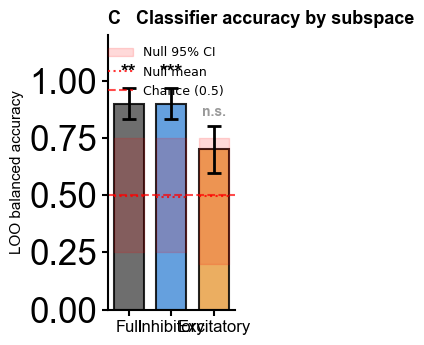

In [17]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

# ── Extract accuracies + per-fold distributions for error bars ────────────────
model_names = ['Full', 'Inhibitory', 'Excitatory']
subset_keys = ['Full', 'Inhibitory', 'Excitatory']

accuracies  = []
perm_pvals  = []
fold_scores = []

for key in subset_keys:
    res  = results_by_subset[key]
    acc  = res['score']
    p    = res['perm_p']
    accuracies.append(acc)
    perm_pvals.append(p)

    # rerun LOO to get per-fold scores for SEM
    idx    = res['idx']
    X_tr   = X_train[:, idx]
    X_tr   = res['imp'].transform(X_train[:, idx]) \
             if hasattr(res.get('imp', None), 'transform') \
             else SimpleImputer(strategy='mean').fit_transform(X_tr)

    # refit scaler on training data
    sc_tmp   = StandardScaler()
    X_tr_s   = sc_tmp.fit_transform(
                   SimpleImputer(strategy='mean').fit_transform(X_tr))

    lda_tmp  = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
    per_fold = cross_val_score(
        lda_tmp, X_tr_s, y_train,
        cv=LeaveOneOut(),
        scoring='balanced_accuracy'
    )
    fold_scores.append(per_fold)
    # print(f'{key:<15} acc={acc:.3f}  '
    #       f'fold mean={per_fold.mean():.3f} ± {per_fold.sem():.3f}  '
    #       f'perm_p={p:.4f}')

sems = [np.std(fs) / np.sqrt(len(fs)) for fs in fold_scores]

# ── Extract permutation null distributions ────────────────────────────────────
perm_ci_low  = []
perm_ci_high = []
perm_means   = []

for key in subset_keys:
    perm_scores = results_by_subset[key]['perm_scores']   # (n_permutations,)
    perm_ci_low.append(np.percentile(perm_scores, 2.5))
    perm_ci_high.append(np.percentile(perm_scores, 97.5))
    perm_means.append(np.mean(perm_scores))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 4))
fig.patch.set_facecolor('white')
colors = ['#555555', '#4A90D9', '#E8A045']
xpos   = np.arange(len(model_names))

ax.bar(xpos, accuracies,
       color=colors, edgecolor='black',
       linewidth=1.5, alpha=0.85, width=0.7)
ax.errorbar(xpos, accuracies, yerr=sems,
            fmt='none', color='black',
            elinewidth=2, capsize=5, capthick=2, zorder=5)

# ── 95% CI of permutation null as error bars on chance line ──────────────────
for i in range(len(model_names)):
    # shaded CI band per bar
    ax.fill_between(
        [xpos[i] - 0.35, xpos[i] + 0.35],
        [perm_ci_low[i],  perm_ci_low[i]],
        [perm_ci_high[i], perm_ci_high[i]],
        color='red', alpha=0.15, zorder=1,
        label='Null 95% CI' if i == 0 else '_nolegend_'
    )
    # mean of null as dotted line per bar
    ax.plot([xpos[i] - 0.35, xpos[i] + 0.35],
            [perm_means[i], perm_means[i]],
            color='red', linewidth=1.5,
            linestyle=':', alpha=0.8,
            label='Null mean' if i == 0 else '_nolegend_')

ax.axhline(0.5, color='red', linewidth=1.5,
           linestyle='--', alpha=0.7, label='Chance (0.5)', zorder=2)

for i, (acc, p, sem) in enumerate(zip(accuracies, perm_pvals, sems)):
    sig       = '***' if p < 0.001 else '**' if p < 0.01 \
                else '*' if p < 0.05 else 'n.s.'
    color_sig = 'black' if sig != 'n.s.' else '#999999'
    fontsize  = 14      if sig != 'n.s.' else 10
    ax.text(i, acc + sem + 0.03, sig,
            ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold',
            fontfamily='Arial', color=color_sig)

ax.set_xticks(xpos)
ax.set_xticklabels(model_names, fontfamily='Arial', fontsize=12)
ax.set_ylabel('LOO balanced accuracy', fontfamily='Arial', fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_title('C   Classifier accuracy by subspace',
             fontsize=13, fontweight='bold',
             fontfamily='Arial', loc='left', pad=8)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))
ax.legend(fontsize=9, frameon=False)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=4)
sns.despine(ax=ax)
plt.tight_layout()
# plt.savefig('./figures/fig5/lda_schematic_C.svg',
#             dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [26]:
rows = []

for i, key in enumerate(subset_keys):
    per_fold = fold_scores[i]
    perm_scores = results_by_subset[key]['perm_scores']

    n_folds = len(per_fold)
    n_perms = len(perm_scores)
    n_max = max(n_folds, n_perms)

    for row_idx in range(n_max):
        rows.append({
            'model': model_names[i],
            'row_idx': row_idx,
            'loo_fold_accuracy': per_fold[row_idx] if row_idx < n_folds else np.nan,
            'permutation_null_score': perm_scores[row_idx] if row_idx < n_perms else np.nan,
            'mean_accuracy': accuracies[i],
            'sem': sems[i],
            'perm_p': perm_pvals[i],
            'perm_null_mean': perm_means[i],
            'perm_null_ci_low_2p5': perm_ci_low[i],
            'perm_null_ci_high_97p5': perm_ci_high[i],
        })

sourceData_5d = pd.DataFrame(rows)
sourceData_5d.to_csv('./sourceData/5d.csv', index=False)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36632\65285192.py:102: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36632\65285192.py:103: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('./figures/fig5_pca_confidence_ellipses.svg',
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


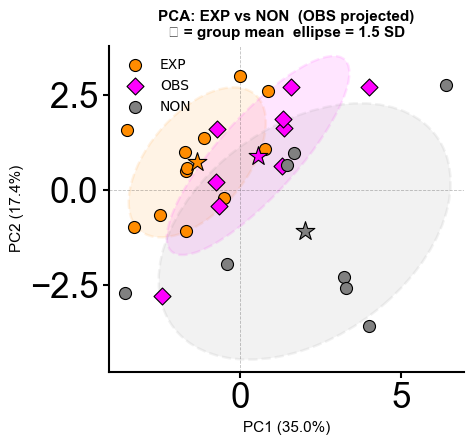


Variance explained: PC1=35.0%  PC2=17.4%  Total=52.4%

PC1 top loadings:
PMv (I)      0.327214
vLS (I)      0.321201
VMHvl (I)    0.317334
BNST (I)     0.291716
lPAG (E)     0.268824
PrL (E)      0.264952
AH (I)       0.264512
vLS (E)      0.264012


In [27]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import numpy as np

# ── PCA fit on EXP + NON training data ────────────────────────────────────────
# Use full region set, same scaling as before
full_idx  = subsets['Full']
imp_full  = SimpleImputer(strategy='mean')
X_tr_full = imp_full.fit_transform(X_train[:, full_idx])
sc_full   = StandardScaler()
X_tr_s    = sc_full.fit_transform(X_tr_full)
X_ob_s    = sc_full.transform(imp_full.transform(X_obs[:, full_idx]))

pca       = PCA(n_components=2)
X_pca     = pca.fit_transform(X_tr_s)
X_obs_pca = pca.transform(X_ob_s)

exp_pca   = X_pca[y_train == 1]   # (12, 2)
non_pca   = X_pca[y_train == 0]   # (8,  2)
obs_pca   = X_obs_pca              # (9,  2)

var_exp   = pca.explained_variance_ratio_

# ── Confidence ellipse helper ─────────────────────────────────────────────────
def confidence_ellipse(x, y, ax, n_std=1.5, facecolor='none', **kwargs):
    """
    Plot a covariance confidence ellipse.
    n_std: number of standard deviations — 1.5 ≈ 68% for 2D Gaussian
    """
    from matplotlib.transforms import Affine2D
    cov    = np.cov(x, y)
    pearr  = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_rx = np.sqrt(1 + pearr)
    ell_ry = np.sqrt(1 - pearr)

    ellipse = Ellipse((0, 0),
                      width=ell_rx * 2, height=ell_ry * 2,
                      facecolor=facecolor, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    transf = (Affine2D()
              .rotate_deg(45)
              .scale(scale_x, scale_y)
              .translate(np.mean(x), np.mean(y)))

    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)
    return ellipse


fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')

groups = [
    (exp_pca, 'EXP', 'darkorange', 'o'),
    (obs_pca, 'OBS', 'magenta',    'D'),
    (non_pca, 'NON', 'gray',       'o'),
]

for data, label, color, marker in groups:
    # scatter
    ax.scatter(data[:, 0], data[:, 1],
               color=color, marker=marker,
               s=75, edgecolors='black',
               linewidths=0.8, zorder=4, label=label)
    # group mean
    ax.scatter(np.mean(data[:, 0]), np.mean(data[:, 1]),
               marker='*', s=200,
               color=color, edgecolors='black',
               linewidths=0.8, zorder=5)
    # confidence ellipse
    confidence_ellipse(
        data[:, 0], data[:, 1], ax,
        n_std=1.5,
        facecolor=color, alpha=0.10,
        edgecolor=color, linewidth=1.8,
        linestyle='--'
    )

ax.axhline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.25)
ax.axvline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.25)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)',
              fontfamily='Arial', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)',
              fontfamily='Arial', fontsize=11)
ax.set_title('PCA: EXP vs NON  (OBS projected)\n★ = group mean  '
             'ellipse = 1.5 SD',
             fontfamily='Arial', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=4)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('./figures/fig5_pca_confidence_ellipses.svg',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nVariance explained: PC1={var_exp[0]*100:.1f}%  '
      f'PC2={var_exp[1]*100:.1f}%  '
      f'Total={var_exp[:2].sum()*100:.1f}%')
print(f'\nPC1 top loadings:')
loadings = pd.Series(pca.components_[0], 
                     index=[region_ids[i] for i in full_idx]
                     ).abs().sort_values(ascending=False)
print(loadings.head(8).to_string())

In [28]:
sourceData_5b = pd.concat([
    pd.DataFrame({'group': 'EXP', 'PC1': exp_pca[:, 0], 'PC2': exp_pca[:, 1]}),
    pd.DataFrame({'group': 'OBS', 'PC1': obs_pca[:, 0], 'PC2': obs_pca[:, 1]}),
    pd.DataFrame({'group': 'NON', 'PC1': non_pca[:, 0], 'PC2': non_pca[:, 1]}),
], ignore_index=True)

sourceData_5b['PC1_explained_variance'] = var_exp[0]
sourceData_5b['PC2_explained_variance'] = var_exp[1]

sourceData_5b.to_csv('./sourceData/5b.csv', index=False)